In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

SUBJECT = "MM15"

!mkdir -p /content/kara_one
!cp "/content/drive/MyDrive/kara_one/{SUBJECT}.tar.bz2" /content/kara_one/

In [ ]:
%cd /content/kara_one
!tar -xvjf {SUBJECT}.tar.bz2

/content/kara_one
p/spoclab/users/szhao/EEG/data/MM15/
p/spoclab/users/szhao/EEG/data/MM15/Acquisition 283 Data.fdt
p/spoclab/users/szhao/EEG/data/MM15/15092014_impedance.docx
p/spoclab/users/szhao/EEG/data/MM15/Acquisition 283 Data.set
p/spoclab/users/szhao/EEG/data/MM15/regression_features_FFT.mat
p/spoclab/users/szhao/EEG/data/MM15/Acquisition 283 Data.cnt
p/spoclab/users/szhao/EEG/data/MM15/regression_features.mat
p/spoclab/users/szhao/EEG/data/MM15/all_features_simple.mat
p/spoclab/users/szhao/EEG/data/MM15/Acquisition 283 Data.rs3
p/spoclab/users/szhao/EEG/data/MM15/Acquisition 283 Data.dap
p/spoclab/users/szhao/EEG/data/MM15/all_features_noICA.mat
p/spoclab/users/szhao/EEG/data/MM15/all_features_ICA.mat
p/spoclab/users/szhao/EEG/data/MM15/kinect_data/
p/spoclab/users/szhao/EEG/data/MM15/kinect_data/54.AnimU
p/spoclab/users/szhao/EEG/data/MM15/kinect_data/74.wav
p/spoclab/users/szhao/EEG/data/MM15/kinect_data/101.AnimU
p/spoclab/users/szhao/EEG/data/MM15/kinect_data/107.3D
p/spoc

In [ ]:
!pip install mne==1.6.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 32.4 MB/s eta 0:00:00


In [ ]:
import glob
import mne

BASE_PATH = f"/content/kara_one/p/spoclab/users/szhao/EEG/data/{SUBJECT}"

cnt_files = glob.glob(BASE_PATH + "/*.cnt")
print(cnt_files)

cnt_path = cnt_files[0]

raw = mne.io.read_raw_cnt(cnt_path, preload=True)
raw.pick_types(eeg=True)

print(raw)

['/content/kara_one/p/spoclab/users/szhao/EEG/data/MM15/Acquisition 283 Data.cnt']


/tmp/ipykernel_1763/2661439346.py:11: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = mne.io.read_raw_cnt(cnt_path, preload=True)


Reading 0 ... 1965599  =      0.000 ...  1965.599 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawCNT | Acquisition 283 Data.cnt, 68 x 1965600 (1965.6 s), ~1019.8 MB, data loaded>


In [ ]:
#raw.plot(n_channels=10, duration=5)

In [ ]:
import scipy.io as sio
import os

epoch_file = os.path.join(BASE_PATH, "epoch_inds.mat")
label_file = os.path.join(BASE_PATH, "kinect_data/labels.txt")

epoch_data = sio.loadmat(epoch_file)

# FIXED
thinking_inds = epoch_data['thinking_inds'][0]

# Load labels
with open(label_file) as f:
    labels = [line.strip() for line in f.readlines()]

print("Total labels:", len(labels))
print("Thinking trials:", len(thinking_inds))

Total labels: 132
Thinking trials: 132


In [ ]:
sfreq = int(raw.info["sfreq"])
epoch_length = sfreq

X = []
clean_labels = []

for i, idx in enumerate(thinking_inds):
    start = int(idx[0][0])   # ✅ FIXED
    stop = start + epoch_length

    if stop <= raw.n_times:
        epoch = raw.get_data(start=start, stop=stop)
        X.append(epoch)
        clean_labels.append(labels[i])

import numpy as np

X = np.array(X)
y = np.array(clean_labels)

print("EEG shape:", X.shape)
print("Labels shape:", y.shape)

EEG shape: (132, 68, 1000)
Labels shape: (132,)


In [ ]:
X_cnn = X[:, :, :, np.newaxis]

print("CNN input shape:", X_cnn.shape)

CNN input shape: (132, 68, 1000, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(8, (3,3), activation='relu', padding='same', input_shape=(68,1000,1)),
    Flatten(),
    Dense(64, activation='relu')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 68, 1000, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 544000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    34,816,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,816,144 (132.81 MB)

 Trainable params: 34,816,144 (132.81 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.predict(X_cnn[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step


array([[2.12792791e-02, 0.00000000e+00, 1.25008859e-02, 0.00000000e+00,
        1.16478465e-03, 1.43401315e-02, 0.00000000e+00, 2.17787176e-02,
        4.84290952e-03, 8.25662166e-03, 4.05465811e-03, 0.00000000e+00,
        2.97102518e-03, 0.00000000e+00, 0.00000000e+00, 1.67450029e-02,
        1.90624837e-02, 8.05559196e-03, 0.00000000e+00, 6.09111413e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.26592545e-02,
        0.00000000e+00, 3.38506792e-03, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 4.02607303e-03, 1.83153357e-02, 0.00000000e+00,
        0.00000000e+00, 6.77193096e-03, 2.38774959e-02, 5.46395592e-03,
        0.00000000e+00, 0.00000000e+00, 3.19308937e-02, 3.95147083e-03,
        0.00000000e+00, 0.00000000e+00, 1.83639117e-04, 0.00000000e+00,
        3.63960490e-03, 0.00000000e+00, 0.00000000e+00, 4.01572697e-03,
        3.46850394e-03, 3.60376574e-03, 0.00000000e+00, 9.90456529e-03,
        2.25233845e-04, 0.00000000e+00, 0.00000000e+00, 0.000000

In [ ]:
features = cnn_model.predict(X_cnn)

print("Feature shape:", features.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step
Feature shape: (132, 64)


In [ ]:
import numpy as np

np.save(f"/content/drive/MyDrive/kara_one/{SUBJECT}_features.npy", features)
np.save(f"/content/drive/MyDrive/kara_one/{SUBJECT}_labels.npy", y)

print(f"{SUBJECT} features saved successfully!")

MM15 features saved successfully!


In [ ]:
import numpy as np

subjects = ["MM05", "MM08", "MM09", "MM10", "MM11", "MM15"]

X_list = []
y_list = []

for sub in subjects:
    X_sub = np.load(f"/content/drive/MyDrive/kara_one/{sub}_features.npy")
    y_sub = np.load(f"/content/drive/MyDrive/kara_one/{sub}_labels.npy")

    X_list.append(X_sub)
    y_list.append(y_sub)

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)

print("Combined feature shape:", X_all.shape)
print("Combined labels shape:", y_all.shape)

Combined feature shape: (824, 64)
Combined labels shape: (824,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_all)

print("Number of classes:", len(le.classes_))

Number of classes: 11


In [ ]:
X_seq = X_all.reshape(X_all.shape[0], 64, 1)

print(X_seq.shape)

(824, 64, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_encoded, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(64,1)),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,611 (68.79 KB)

 Trainable params: 17,611 (68.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0835 - loss: 2.3995 - val_accuracy: 0.0606 - val_loss: 2.3992
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0892 - loss: 2.3981 - val_accuracy: 0.0909 - val_loss: 2.3994
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0911 - loss: 2.3978 - val_accuracy: 0.0606 - val_loss: 2.4007
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0740 - loss: 2.3990 - val_accuracy: 0.0909 - val_loss: 2.4012
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0873 - loss: 2.3976 - val_accuracy: 0.1136 - val_loss: 2.4002
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0949 - loss: 2.3977 - val_accuracy: 0.0909 - val_loss: 2.4022
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0987 - loss: 2.3974 - val_accuracy: 0.0909 - val_loss: 2.4016
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0702 - loss: 2.3976 - val_accuracy: 0.1136 - v

In [ ]:
y_pred = model.predict(X_test)

import numpy as np

y_pred_labels = np.argmax(y_pred, axis=1)

from sklearn.metrics import accuracy_score

print("Top-1 Accuracy:", accuracy_score(y_test, y_pred_labels)*100)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Top-1 Accuracy: 6.666666666666667


In [ ]:
top3 = np.argsort(y_pred, axis=1)[:, -3:]

correct = sum([y_test[i] in top3[i] for i in range(len(y_test))])

print("Top-3 Accuracy:", correct / len(y_test)*100)

Top-3 Accuracy: 21.21212121212121


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Dropout
)
from tensorflow.keras.models import Model

input_layer = Input(shape=(64, 1))

# Project input to higher dimension
x = Dense(64)(input_layer)

# Transformer block
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = LayerNormalization()(x + attn_output)

# Feed-forward
ff = Dense(128, activation='relu')(x)
ff = Dense(64)(ff)

x = LayerNormalization()(x + ff)

# Pooling
x = GlobalAveragePooling1D()(x)

# Output layer
output = Dense(len(le.classes_), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 64)    │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ dense_2[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ dense_2[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 64)    │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 11)        │        715 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 84,043 (328.29 KB)

 Trainable params: 84,043 (328.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.0892 - loss: 2.8855 - val_accuracy: 0.1136 - val_loss: 2.4893
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0873 - loss: 2.4370 - val_accuracy: 0.0909 - val_loss: 2.4391
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0892 - loss: 2.4342 - val_accuracy: 0.0758 - val_loss: 2.4479
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0835 - loss: 2.4516 - val_accuracy: 0.0909 - val_loss: 2.4132
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0835 - loss: 2.4622 - val_accuracy: 0.0909 - val_loss: 2.4116
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0702 - loss: 2.4398 - val_accuracy: 0.0985 - val_loss: 2.4264
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0873 - loss: 2.4462 - val_accuracy: 0.0606 - val_loss: 2.4390
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0892 - loss: 2.4384 - val_accuracy: 0.0909 - v

In [ ]:
y_pred = model.predict(X_test)

import numpy as np

y_pred_labels = np.argmax(y_pred, axis=1)

from sklearn.metrics import accuracy_score

print("Top-1 Accuracy:", accuracy_score(y_test, y_pred_labels)*100)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Top-1 Accuracy: 10.909090909090908


In [ ]:
top3 = np.argsort(y_pred, axis=1)[:, -3:]

correct = sum([y_test[i] in top3[i] for i in range(len(y_test))])

print("Top-3 Accuracy:", correct / len(y_test) * 100)

Top-3 Accuracy: 26.666666666666668


In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
label_embeddings = sbert.encode(le.classes_)

pred_words = le.inverse_transform(y_pred_labels)
true_words = le.inverse_transform(y_test)

pred_embeddings = sbert.encode(pred_words)
true_embeddings = sbert.encode(true_words)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

correct = 0

for i in range(len(y_test)):
    true_word = le.inverse_transform([y_test[i]])[0]

    candidates = le.inverse_transform(top3[i])

    true_emb = sbert.encode([true_word])[0]
    cand_emb = sbert.encode(candidates)

    sims = cosine_similarity([true_emb], cand_emb)[0]

    if max(sims) > 0.5:
        correct += 1

print("Semantic Top-3 Accuracy:", correct / len(y_test) * 100)

Semantic Top-3 Accuracy: 41.21212121212121


In [ ]:
import numpy as np

top3 = np.argsort(y_pred, axis=1)[:, -3:]

top3_words = []

for i in range(len(top3)):
    words = le.inverse_transform(top3[i])
    top3_words.append(words)

# Show first 5 predictions
for i in range(5):
    print(f"Sample {i}:")
    print("Predicted:", top3_words[i])
    print("Actual   :", le.inverse_transform([y_test[i]])[0])
    print()

Sample 0:
Predicted: ['/iy/' '/piy/' '/tiy/']
Actual   : /tiy/

Sample 1:
Predicted: ['/iy/' '/piy/' '/tiy/']
Actual   : /tiy/

Sample 2:
Predicted: ['pot' '/piy/' '/tiy/']
Actual   : /piy/

Sample 3:
Predicted: ['/iy/' '/piy/' '/tiy/']
Actual   : /uw/

Sample 4:
Predicted: ['/iy/' '/piy/' '/tiy/']
Actual   : knew



In [ ]:
import numpy as np
print(np.bincount(y_train))

[67 61 57 62 58 57 59 56 59 59 64]


In [ ]:
import numpy as np

# Get Top-3 indices
top3 = np.argsort(y_pred, axis=1)[:, -3:]

top3_words = []

for i in range(len(top3)):
    words = le.inverse_transform(top3[i])
    top3_words.append(words)

# 🔥 Collect samples with different predictions
selected_indices = []
seen_predictions = set()

for i in range(len(top3_words)):
    pred_tuple = tuple(top3_words[i])  # convert to tuple for set

    if pred_tuple not in seen_predictions:
        seen_predictions.add(pred_tuple)
        selected_indices.append(i)

    if len(selected_indices) >= 5:
        break

# If not enough unique predictions, fill randomly
if len(selected_indices) < 5:
    remaining = list(set(range(len(y_test))) - set(selected_indices))
    extra = np.random.choice(remaining, size=5-len(selected_indices), replace=False)
    selected_indices.extend(extra)

# Show results
for i in selected_indices:
    print(f"Sample {i}:")
    print("Predicted:", top3_words[i])
    print("Actual   :", le.inverse_transform([y_test[i]])[0])
    print()

Sample 0:
Predicted: ['/iy/' '/piy/' '/tiy/']
Actual   : /tiy/

Sample 2:
Predicted: ['pot' '/piy/' '/tiy/']
Actual   : /piy/

Sample 43:
Predicted: ['/iy/' '/piy/' '/tiy/']
Actual   : knew

Sample 99:
Predicted: ['pot' '/piy/' '/tiy/']
Actual   : /tiy/

Sample 91:
Predicted: ['/iy/' '/piy/' '/tiy/']
Actual   : /iy/



In [ ]:
def predict_thought(eeg_sample):
    # reshape for CNN
    eeg_sample = eeg_sample[np.newaxis, :, :, np.newaxis]

    # CNN features
    feat = cnn_model.predict(eeg_sample)

    # reshape for transformer
    feat_seq = feat.reshape(1, 64, 1)

    # prediction
    pred = model.predict(feat_seq)

    top3 = np.argsort(pred, axis=1)[:, -3:][0]

    words = le.inverse_transform(top3)

    return words




In [ ]:
sample = X[0]

predicted_words = predict_thought(sample)

print("Predicted words:", predicted_words)
print("Actual word:", y[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted words: ['/iy/' '/piy/' '/tiy/']
Actual word: /iy/


In [ ]:
top3 = np.argsort(y_pred, axis=1)[:, -3:]

correct = 0

for i in range(len(y_test)):
    true_word = le.inverse_transform([y_test[i]])[0]
    candidates = le.inverse_transform(top3[i])

    true_emb = sbert.encode([true_word])[0]
    cand_emb = sbert.encode(candidates)

    sims = cosine_similarity([true_emb], cand_emb)[0]

    if max(sims) > 0.5:
        correct += 1

final_top3 = correct / len(y_test) * 100

print("FINAL Semantic Top-3 Accuracy:", final_top3)

FINAL Semantic Top-3 Accuracy: 41.21212121212121


<Figure size 800x600 with 0 Axes>

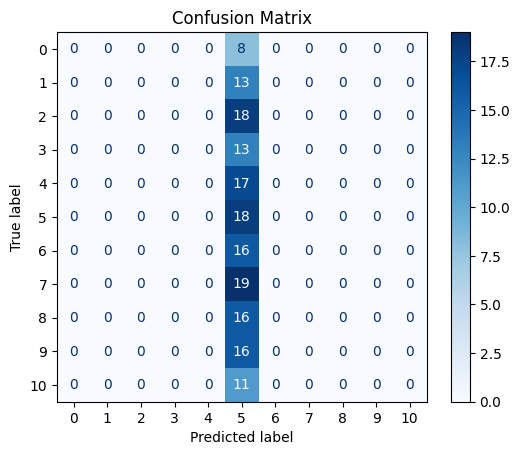

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred_labels = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)

# Plot
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.show()

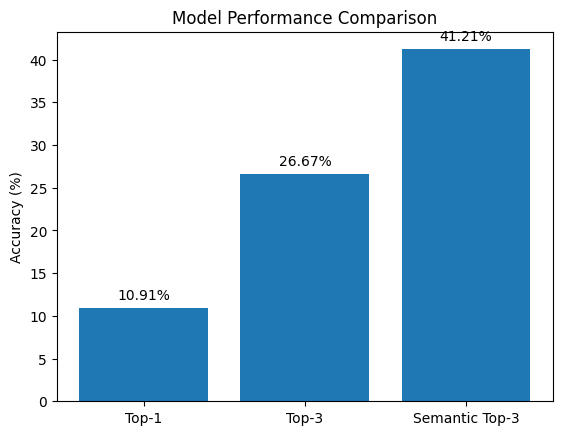

In [ ]:
from sklearn.metrics import accuracy_score

top1 = accuracy_score(y_test, y_pred_labels) * 100

# Top-3
top3 = np.argsort(y_pred, axis=1)[:, -3:]
top3_acc = np.mean([y_test[i] in top3[i] for i in range(len(y_test))]) * 100

# Semantic Top-3 (your final metric)
semantic_top3 = final_top3

# Plot
labels = ['Top-1', 'Top-3', 'Semantic Top-3']
values = [top1, top3_acc, semantic_top3]

plt.figure()
plt.bar(labels, values)

plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()

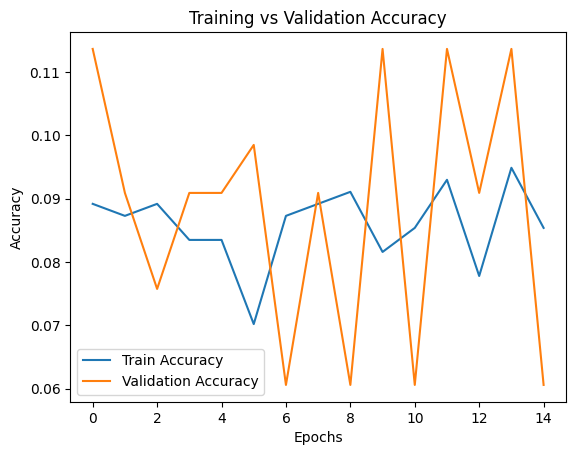

In [ ]:
plt.figure()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

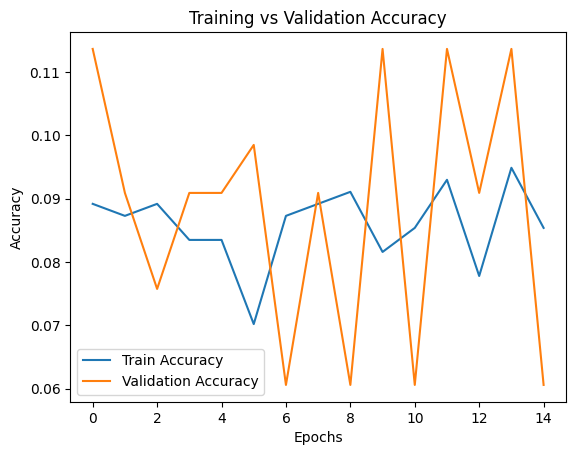

In [ ]:
plt.figure()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

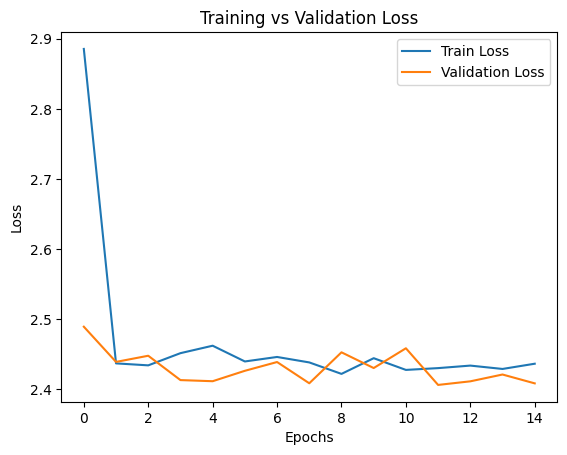

In [ ]:
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

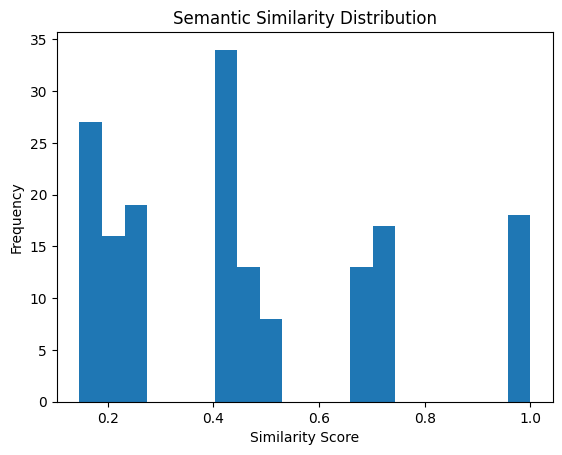

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = []

for i in range(len(y_test)):
    true_word = le.inverse_transform([y_test[i]])[0]
    pred_word = le.inverse_transform([y_pred_labels[i]])[0]

    true_emb = sbert.encode([true_word])[0]
    pred_emb = sbert.encode([pred_word])[0]

    sim = cosine_similarity([true_emb], [pred_emb])[0][0]
    similarities.append(sim)

plt.figure()
plt.hist(similarities, bins=20)

plt.title("Semantic Similarity Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()

In [ ]:
print(le.classes_)

['/diy/' '/iy/' '/m/' '/n/' '/piy/' '/tiy/' '/uw/' 'gnaw' 'knew' 'pat'
 'pot']


In [ ]:
import numpy as np

# Pick one sample
sample = X_test[0]

# Add batch dimension
sample = np.expand_dims(sample, axis=0)